# Analiza wad produkcyjnych — marzec 2026

**Źródło danych:** `raport wad marzec 2026 - katalog_PowerBI.xlsx`  
**Zakres:** 178 rekordów · 858 wadliwych sztuk  
**Kolumny:** Wydział · Kierunek (PL/EX) · Grupa ogólna · Wada · Ilość

---
## Spis analiz
1. [Wczytanie i przegląd danych](#1)
2. [Analiza Pareto 80/20](#2)
3. [Ranking wydziałów](#3)
4. [Kategorie wad](#4)
5. [Heatmap: Wydział × Kategoria](#5)
6. [PL vs EX](#6)
7. [Grupy produktów](#7)
8. [Top 5 wad per wydział](#8)
9. [Macierz produkt × wada](#9)
10. [Export raportu XLSX](#10)
11. [Export CSV dla PowerBI](#11)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Globalne ustawienia wykresów
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PLIK = 'raport wad marzec 2026 - katalog_PowerBI.xlsx'
TOTAL = 858  # suma kontrolna
print('Pakiety załadowane.')

Pakiety załadowane.


---
## 1. Wczytanie i przegląd danych <a id='1'></a>

In [2]:
df = pd.read_excel(PLIK)
df.columns = ['Wydzial', 'Kierunek', 'Grupa', 'Wada', 'Ilosc']

print(f'Wymiary: {df.shape[0]} wierszy × {df.shape[1]} kolumn')
print(f'Łączna ilość wad: {df["Ilosc"].sum()} (kontrola: {TOTAL})')
df.head(10)

Wymiary: 178 wierszy × 5 kolumn
Łączna ilość wad: 858 (kontrola: 858)


,Wydzial,Kierunek,Grupa,Wada,Ilosc
0,Z2WF,PL,Futryny,Brak w dostawie - Brak w dostawie,1
1,Z1WD,PL,Drzwi,Błąd produkcji - błąd frezowania,1
2,Z1WD,PL,Futryny,Błąd produkcji - błąd frezowania,6
3,Z2WD,PL,Drzwi,Błąd produkcji - błąd frezowania,4
4,Z2WF,EX,Futryny,Błąd produkcji - błąd frezowania,1
5,Z2WF,PL,Futryny,Błąd produkcji - błąd frezowania,6
6,Z3WD,EX,Futryny,Błąd produkcji - błąd frezowania,1
7,Z3WD,PL,Drzwi,Błąd produkcji - błąd frezowania,2
8,Z3WD,PL,Futryny,Błąd produkcji - błąd frezowania,4
9,Z4WD,PL,Drzwi,Błąd produkcji - błąd frezowania,1


In [3]:
print('=== STATYSTYKI PODSTAWOWE ===')
print(df['Ilosc'].describe())
print(f'\nLiczba unikalnych wydziałów: {df["Wydzial"].nunique()} → {sorted(df["Wydzial"].unique())}')
print(f'Liczba unikalnych kierunków: {df["Kierunek"].nunique()} → {sorted(df["Kierunek"].unique())}')
print(f'Liczba unikalnych grup:      {df["Grupa"].nunique()} → {sorted(df["Grupa"].unique())}')
print(f'Liczba unikalnych wad:       {df["Wada"].nunique()}')
print(f'Brakujące wartości:\n{df.isnull().sum()}')

=== STATYSTYKI PODSTAWOWE ===
count    178.000000
mean       4.820225
std        7.538319
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       60.000000
Name: Ilosc, dtype: float64

Liczba unikalnych wydziałów: 7 → ['Z1WD', 'Z2WD', 'Z2WF', 'Z3WD', 'Z3WO', 'Z4WD', 'Z4WF']
Liczba unikalnych kierunków: 2 → ['EX', 'PL']
Liczba unikalnych grup:      5 → ['Drzwi', 'Futryny', 'Listwa,opaska,panel kpl', 'Listwa,opaska,panel szt', 'Okna']
Liczba unikalnych wad:       32
Brakujące wartości:
Wydzial     0
Kierunek    0
Grupa       0
Wada        0
Ilosc       0
dtype: int64


In [4]:
# Dodajemy kolumnę kategorii wady (używana w wielu analizach)
def kategoryzuj(wada):
    if 'Uszkodzenia' in wada:
        return 'Uszkodzenia mechaniczne'
    elif 'Wada powierzchni' in wada:
        return 'Wady powierzchni'
    elif 'Wada konstrukcji' in wada:
        return 'Wady konstrukcji'
    elif 'Wada okuć' in wada:
        return 'Wady okuć'
    elif 'Błąd produkcji' in wada:
        return 'Błędy produkcji'
    elif 'Niezgodność z zamówieniem' in wada:
        return 'Niezgodność z zamówieniem'
    elif 'Brak w dostawie' in wada:
        return 'Brak w dostawie'
    return 'Inne'

df['Kategoria'] = df['Wada'].apply(kategoryzuj)
print('Kategorie wad:')
print(df.groupby('Kategoria')['Ilosc'].sum().sort_values(ascending=False))

Kategorie wad:
Kategoria
Wady powierzchni             313
Wady okuć                    142
Niezgodność z zamówieniem    136
Błędy produkcji              119
Uszkodzenia mechaniczne       85
Wady konstrukcji              62
Brak w dostawie                1
Name: Ilosc, dtype: int64


---
## 2. Analiza Pareto 80/20 <a id='2'></a>
Które pojedyncze wady generują 80% wszystkich problemów?

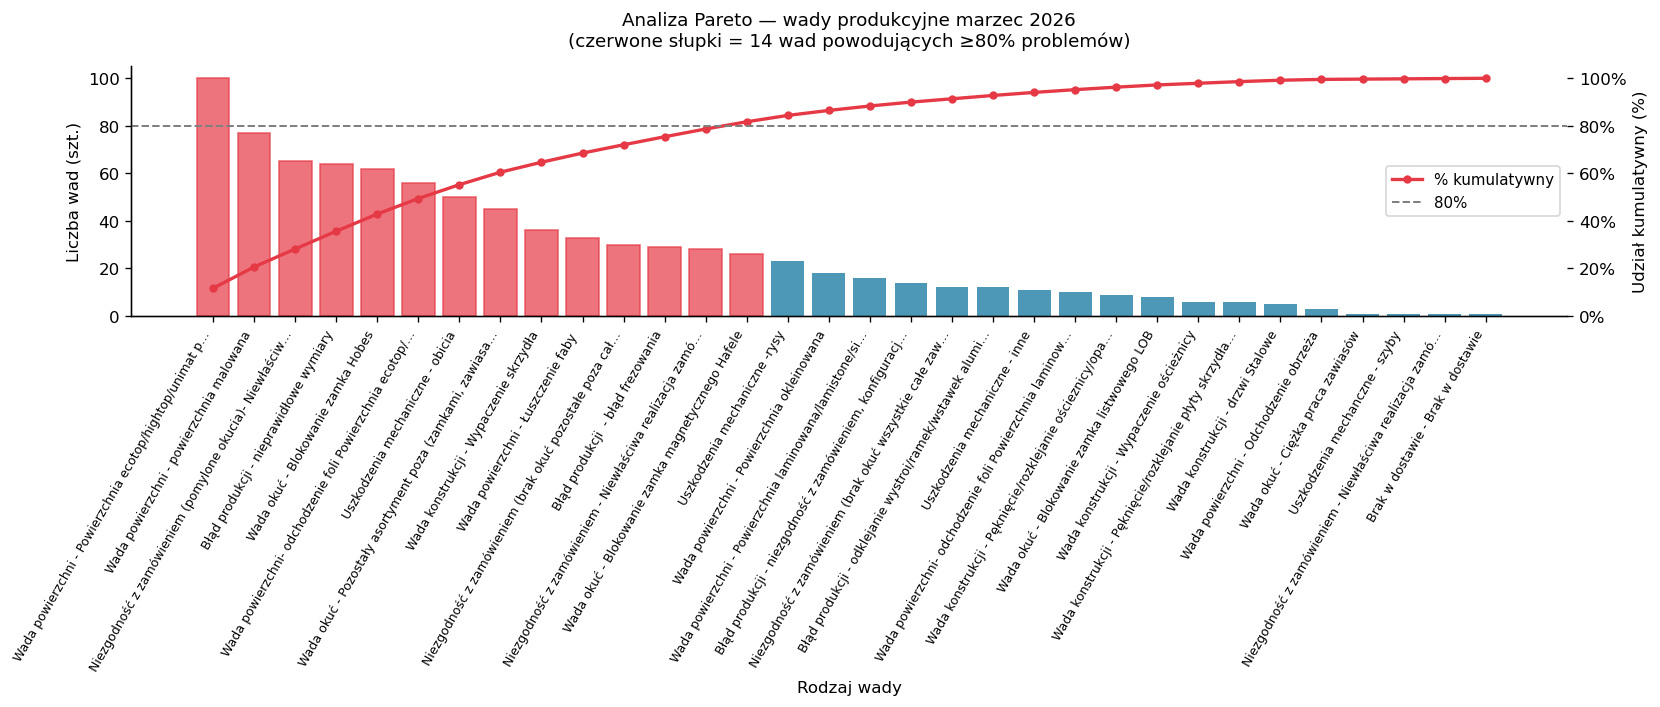


14 wad odpowiada za ≥80% wszystkich 858 sztuk:
                                                    Ilość  Udział_proc
Wada                                                                  
Wada powierzchni - Powierzchnia ecotop/hightop/...    100         11.7
Wada powierzchni - powierzchnia malowana               77          9.0
Niezgodność z zamówieniem (pomylone okucia)- Ni...     65          7.6
Błąd produkcji - nieprawidłowe wymiary                 64          7.5
Wada okuć - Blokowanie zamka Hobes                     62          7.2
Wada powierzchni- odchodzenie foli Powierzchnia...     56          6.5
Uszkodzenia mechaniczne - obicia                       50          5.8
Wada okuć - Pozostały asortyment poza (zamkami,...     45          5.2
Wada konstrukcji - Wypaczenie skrzydła                 36          4.2
Wada powierzchni - Łuszczenie faby                     33          3.8
Niezgodność z zamówieniem (brak okuć pozostałe ...     30          3.5
Błąd produkcji  - błąd frezow

In [5]:
pareto = df.groupby('Wada')['Ilosc'].sum().sort_values(ascending=False)
pareto_cum = pareto.cumsum() / pareto.sum() * 100

# Skróć długie nazwy wad do wykresu
def skroc(nazwa, n=55):
    return nazwa[:n] + '…' if len(nazwa) > n else nazwa

labels = [skroc(w) for w in pareto.index]

fig, ax1 = plt.subplots(figsize=(14, 6))
bars = ax1.bar(range(len(pareto)), pareto.values, color='#2E86AB', alpha=0.85)
ax1.set_xticks(range(len(pareto)))
ax1.set_xticklabels(labels, rotation=60, ha='right', fontsize=7.5)
ax1.set_ylabel('Liczba wad (szt.)', fontsize=10)
ax1.set_xlabel('Rodzaj wady', fontsize=10)

ax2 = ax1.twinx()
ax2.plot(range(len(pareto)), pareto_cum.values, color='#E63946', marker='o', ms=4, lw=2, label='% kumulatywny')
ax2.axhline(80, color='gray', ls='--', lw=1.2, label='80%')
ax2.set_ylabel('Udział kumulatywny (%)', fontsize=10)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

# Podświetl próg 80%
prog = int((pareto_cum <= 80).sum())
for i in range(prog + 1):
    bars[i].set_color('#E63946')
    bars[i].set_alpha(0.7)

ax2.legend(loc='center right', fontsize=9)
plt.title(f'Analiza Pareto — wady produkcyjne marzec 2026\n(czerwone słupki = {prog+1} wad powodujących ≥80% problemów)', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('pareto_wady.png', bbox_inches='tight')
plt.show()

print(f'\n{prog+1} wad odpowiada za ≥80% wszystkich {TOTAL} sztuk:')
print(pareto.head(prog+1).to_frame('Ilość').assign(Udział_proc=lambda x: (x['Ilość']/TOTAL*100).round(1)))

---
## 3. Ranking wydziałów <a id='3'></a>

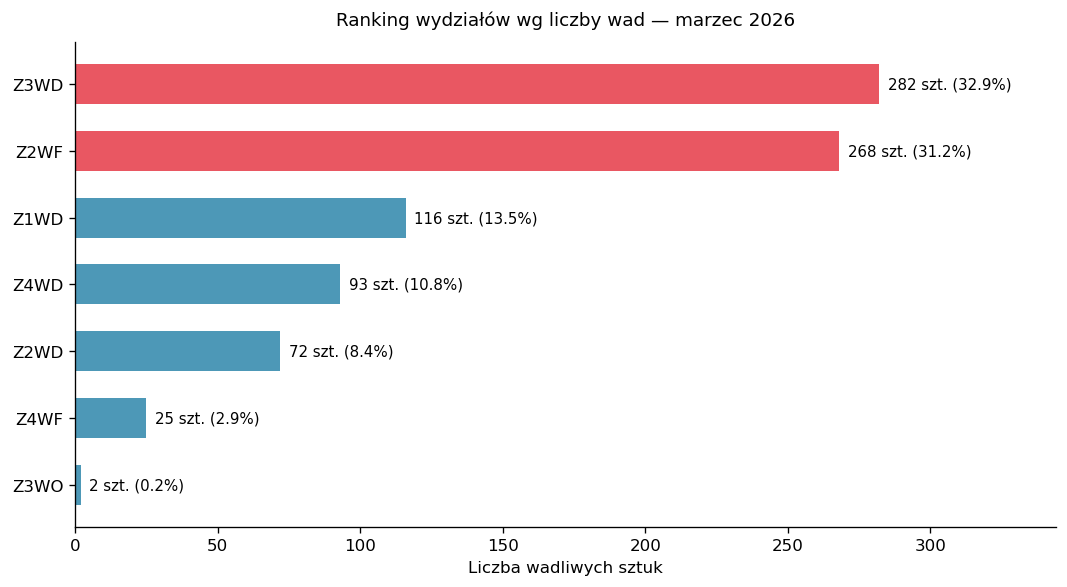

         Ilość  Udział %  Skumulowany %
Wydzial                                
Z3WD       282      32.9           32.9
Z2WF       268      31.2           64.1
Z1WD       116      13.5           77.6
Z4WD        93      10.8           88.4
Z2WD        72       8.4           96.8
Z4WF        25       2.9           99.7
Z3WO         2       0.2           99.9


In [6]:
wydzial = df.groupby('Wydzial')['Ilosc'].sum().sort_values(ascending=True)
pct = (wydzial / TOTAL * 100).round(1)

colors = ['#2E86AB' if v < wydzial.max() * 0.5 else '#E63946' for v in wydzial.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(wydzial.index, wydzial.values, color=colors, alpha=0.85, height=0.6)

for bar, val, p in zip(bars, wydzial.values, pct.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val} szt. ({p}%)', va='center', fontsize=9)

ax.set_xlabel('Liczba wadliwych sztuk', fontsize=10)
ax.set_title('Ranking wydziałów wg liczby wad — marzec 2026', fontsize=11, pad=10)
ax.set_xlim(0, wydzial.max() * 1.22)
plt.tight_layout()
plt.savefig('ranking_wydzialow.png', bbox_inches='tight')
plt.show()

tabela_wydzial = wydzial.sort_values(ascending=False).to_frame('Ilość')
tabela_wydzial['Udział %'] = (tabela_wydzial['Ilość'] / TOTAL * 100).round(1)
tabela_wydzial['Skumulowany %'] = tabela_wydzial['Udział %'].cumsum().round(1)
print(tabela_wydzial)

---
## 4. Kategorie wad <a id='4'></a>

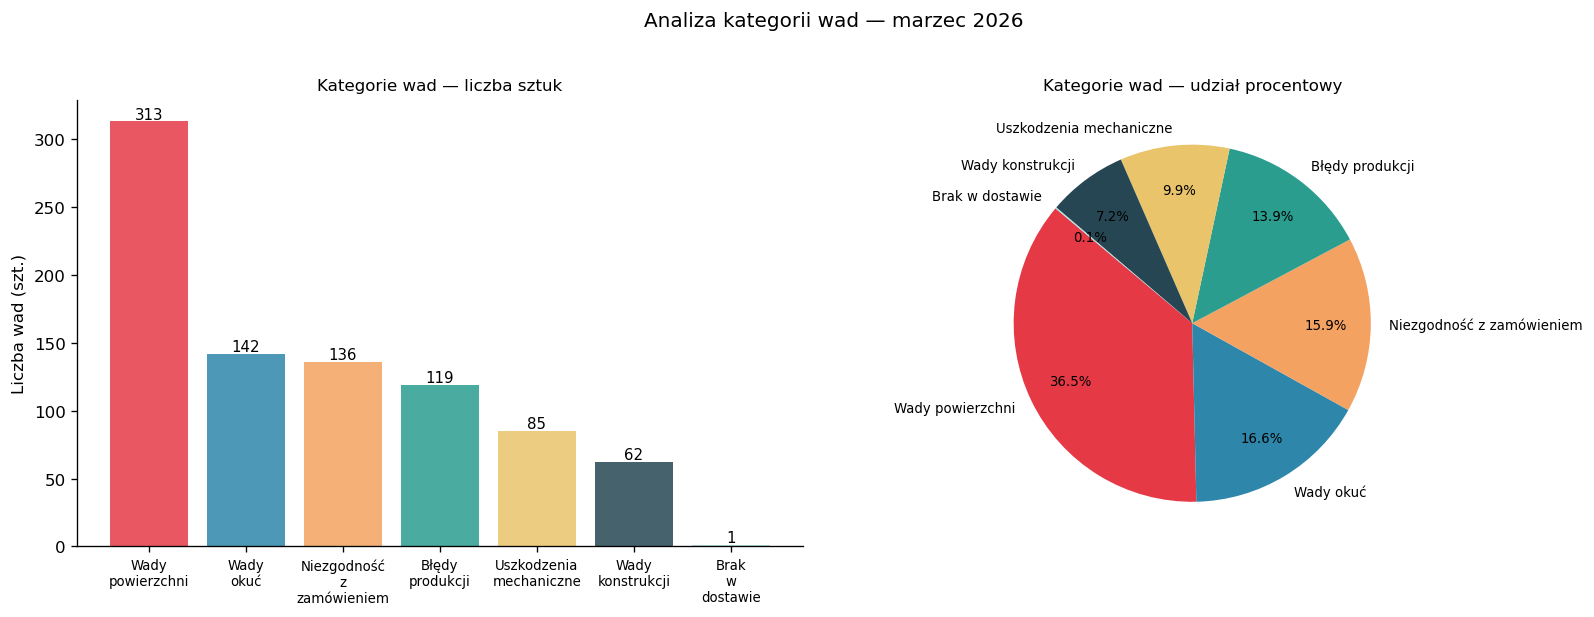

                           Ilość  Udział %
Kategoria                                 
Wady powierzchni             313      36.5
Wady okuć                    142      16.6
Niezgodność z zamówieniem    136      15.9
Błędy produkcji              119      13.9
Uszkodzenia mechaniczne       85       9.9
Wady konstrukcji              62       7.2
Brak w dostawie                1       0.1


In [7]:
kat = df.groupby('Kategoria')['Ilosc'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres słupkowy
palette = ['#E63946','#2E86AB','#F4A261','#2A9D8F','#E9C46A','#264653','#A8DADC']
ax = axes[0]
bars = ax.bar(range(len(kat)), kat.values, color=palette[:len(kat)], alpha=0.85)
ax.set_xticks(range(len(kat)))
ax.set_xticklabels([k.replace(' ', '\n') for k in kat.index], fontsize=8)
ax.set_ylabel('Liczba wad (szt.)')
ax.set_title('Kategorie wad — liczba sztuk', fontsize=10)
for bar, val in zip(bars, kat.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, str(val), ha='center', fontsize=9)

# Wykres kołowy
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    kat.values, labels=kat.index, colors=palette[:len(kat)],
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('Kategorie wad — udział procentowy', fontsize=10)

plt.suptitle('Analiza kategorii wad — marzec 2026', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('kategorie_wad.png', bbox_inches='tight')
plt.show()

print(kat.to_frame('Ilość').assign(**{'Udział %': (kat / TOTAL * 100).round(1)}))

---
## 5. Heatmap: Wydział × Kategoria wady <a id='5'></a>

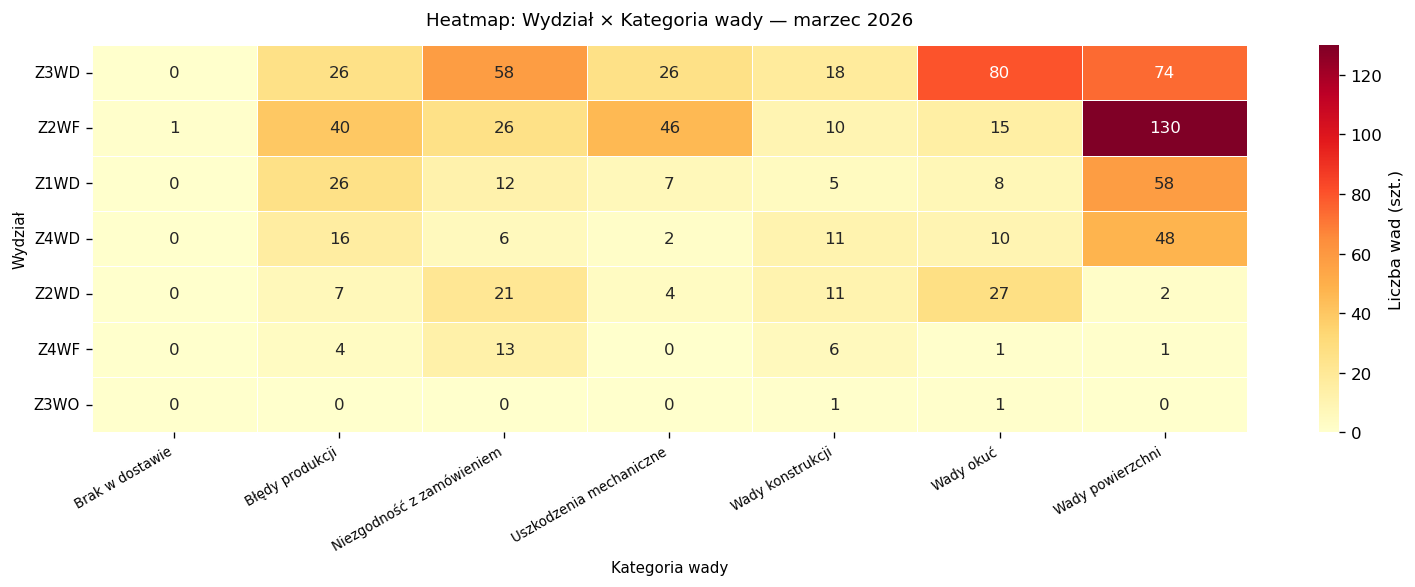

Kategoria  Brak w dostawie  Błędy produkcji  Niezgodność z zamówieniem  \
Wydzial                                                                  
Z3WD                     0               26                         58   
Z2WF                     1               40                         26   
Z1WD                     0               26                         12   
Z4WD                     0               16                          6   
Z2WD                     0                7                         21   
Z4WF                     0                4                         13   
Z3WO                     0                0                          0   

Kategoria  Uszkodzenia mechaniczne  Wady konstrukcji  Wady okuć  \
Wydzial                                                           
Z3WD                            26                18         80   
Z2WF                            46                10         15   
Z1WD                             7                 5          8  

In [8]:
pivot = df.pivot_table(index='Wydzial', columns='Kategoria', values='Ilosc', aggfunc='sum', fill_value=0)

# Posortuj wiersze wg sumy malejąco
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    pivot, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Liczba wad (szt.)'}
)
ax.set_title('Heatmap: Wydział × Kategoria wady — marzec 2026', fontsize=11, pad=12)
ax.set_xlabel('Kategoria wady', fontsize=9)
ax.set_ylabel('Wydział', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_wydzial_kategoria.png', bbox_inches='tight')
plt.show()

# Tabela z sumami
pivot_display = pivot.copy()
pivot_display['SUMA'] = pivot_display.sum(axis=1)
print(pivot_display)

---
## 6. Analiza PL vs EX <a id='6'></a>

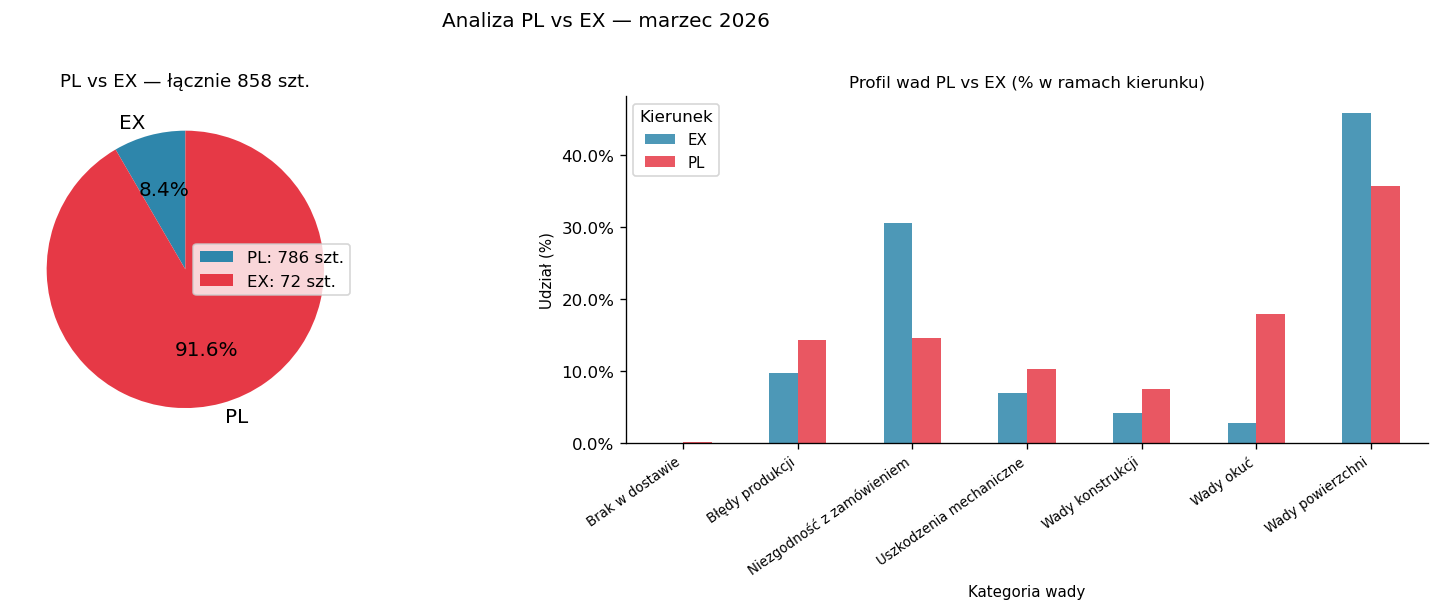


Liczba wad per kierunek i kategoria:
Kategoria  Brak w dostawie  Błędy produkcji  Niezgodność z zamówieniem  \
Kierunek                                                                 
EX                       0                7                         22   
PL                       1              112                        114   

Kategoria  Uszkodzenia mechaniczne  Wady konstrukcji  Wady okuć  \
Kierunek                                                          
EX                               5                 3          2   
PL                              80                59        140   

Kategoria  Wady powierzchni  
Kierunek                     
EX                       33  
PL                      280  

Udział % (w ramach kierunku):
Kategoria  Brak w dostawie  Błędy produkcji  Niezgodność z zamówieniem  \
Kierunek                                                                 
EX                     0.0              9.7                       30.6   
PL                     

In [9]:
pl_ex_total = df.groupby('Kierunek')['Ilosc'].sum()
pl_ex_kat = df.groupby(['Kierunek', 'Kategoria'])['Ilosc'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy — udział PL vs EX ogółem
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    pl_ex_total.values, labels=pl_ex_total.index,
    colors=['#2E86AB', '#E63946'], autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
ax.set_title(f'PL vs EX — łącznie {TOTAL} szt.', fontsize=11)
ax.legend([f'PL: {pl_ex_total["PL"]} szt.', f'EX: {pl_ex_total["EX"]} szt.'], fontsize=10)

# Prawy — kategorie wad per kierunek (normalizowane %)
ax2 = axes[1]
pl_ex_pct = pl_ex_kat.div(pl_ex_kat.sum(axis=1), axis=0) * 100
palette7 = ['#E63946','#2E86AB','#F4A261','#2A9D8F','#E9C46A','#264653','#A8DADC']
pl_ex_pct.T.plot(kind='bar', ax=ax2, color=['#2E86AB','#E63946'], alpha=0.85)
ax2.set_title('Profil wad PL vs EX (% w ramach kierunku)', fontsize=10)
ax2.set_xlabel('Kategoria wady', fontsize=9)
ax2.set_ylabel('Udział (%)', fontsize=9)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(title='Kierunek', fontsize=9)

plt.suptitle('Analiza PL vs EX — marzec 2026', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('pl_vs_ex.png', bbox_inches='tight')
plt.show()

print('\nLiczba wad per kierunek i kategoria:')
print(pl_ex_kat)
print('\nUdział % (w ramach kierunku):')
print(pl_ex_pct.round(1))

---
## 7. Grupy produktów <a id='7'></a>

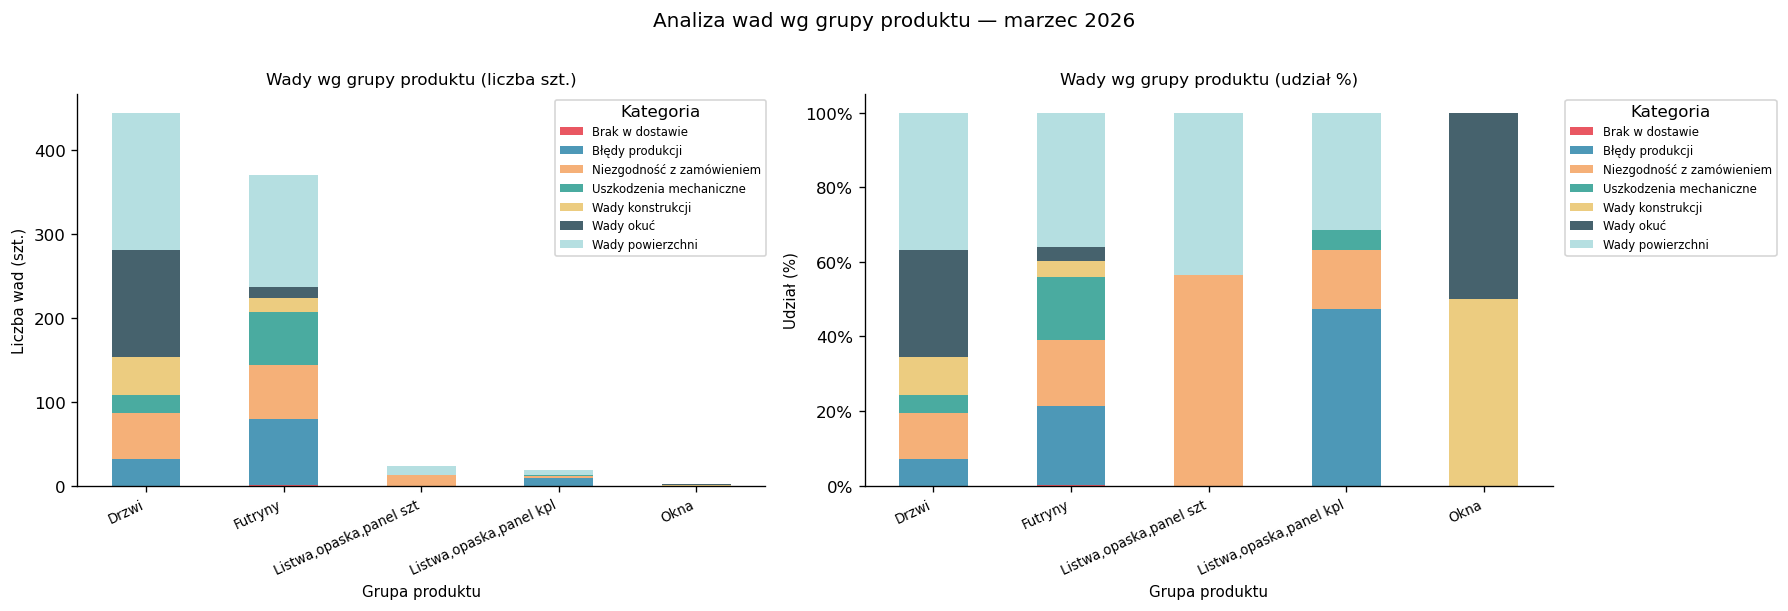

Kategoria                Brak w dostawie  Błędy produkcji  \
Grupa                                                       
Drzwi                                  0               32   
Futryny                                1               78   
Listwa,opaska,panel szt                0                0   
Listwa,opaska,panel kpl                0                9   
Okna                                   0                0   

Kategoria                Niezgodność z zamówieniem  Uszkodzenia mechaniczne  \
Grupa                                                                         
Drzwi                                           55                       21   
Futryny                                         65                       63   
Listwa,opaska,panel szt                         13                        0   
Listwa,opaska,panel kpl                          3                        1   
Okna                                             0                        0   

Kategoria         

In [10]:
grupa_kat = df.pivot_table(index='Grupa', columns='Kategoria', values='Ilosc', aggfunc='sum', fill_value=0)
# Posortuj grupy wg sumy
suma_grup = grupa_kat.sum(axis=1).sort_values(ascending=False)
grupa_kat = grupa_kat.loc[suma_grup.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar bezwzględny
ax = axes[0]
palette7 = ['#E63946','#2E86AB','#F4A261','#2A9D8F','#E9C46A','#264653','#A8DADC']
grupa_kat.plot(kind='bar', stacked=True, ax=ax, color=palette7[:len(grupa_kat.columns)], alpha=0.85)
ax.set_title('Wady wg grupy produktu (liczba szt.)', fontsize=10)
ax.set_xlabel('Grupa produktu', fontsize=9)
ax.set_ylabel('Liczba wad (szt.)', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
ax.legend(title='Kategoria', fontsize=7, bbox_to_anchor=(1.01, 1))

# Stacked bar procentowy
ax2 = axes[1]
grupa_pct = grupa_kat.div(grupa_kat.sum(axis=1), axis=0) * 100
grupa_pct.plot(kind='bar', stacked=True, ax=ax2, color=palette7[:len(grupa_pct.columns)], alpha=0.85)
ax2.set_title('Wady wg grupy produktu (udział %)', fontsize=10)
ax2.set_xlabel('Grupa produktu', fontsize=9)
ax2.set_ylabel('Udział (%)', fontsize=9)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(title='Kategoria', fontsize=7, bbox_to_anchor=(1.01, 1))

plt.suptitle('Analiza wad wg grupy produktu — marzec 2026', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('grupy_produktow.png', bbox_inches='tight')
plt.show()

tabela_grupy = grupa_kat.copy()
tabela_grupy['SUMA'] = tabela_grupy.sum(axis=1)
tabela_grupy['Udział %'] = (tabela_grupy['SUMA'] / TOTAL * 100).round(1)
print(tabela_grupy)

---
## 8. Top 5 wad per wydział <a id='8'></a>

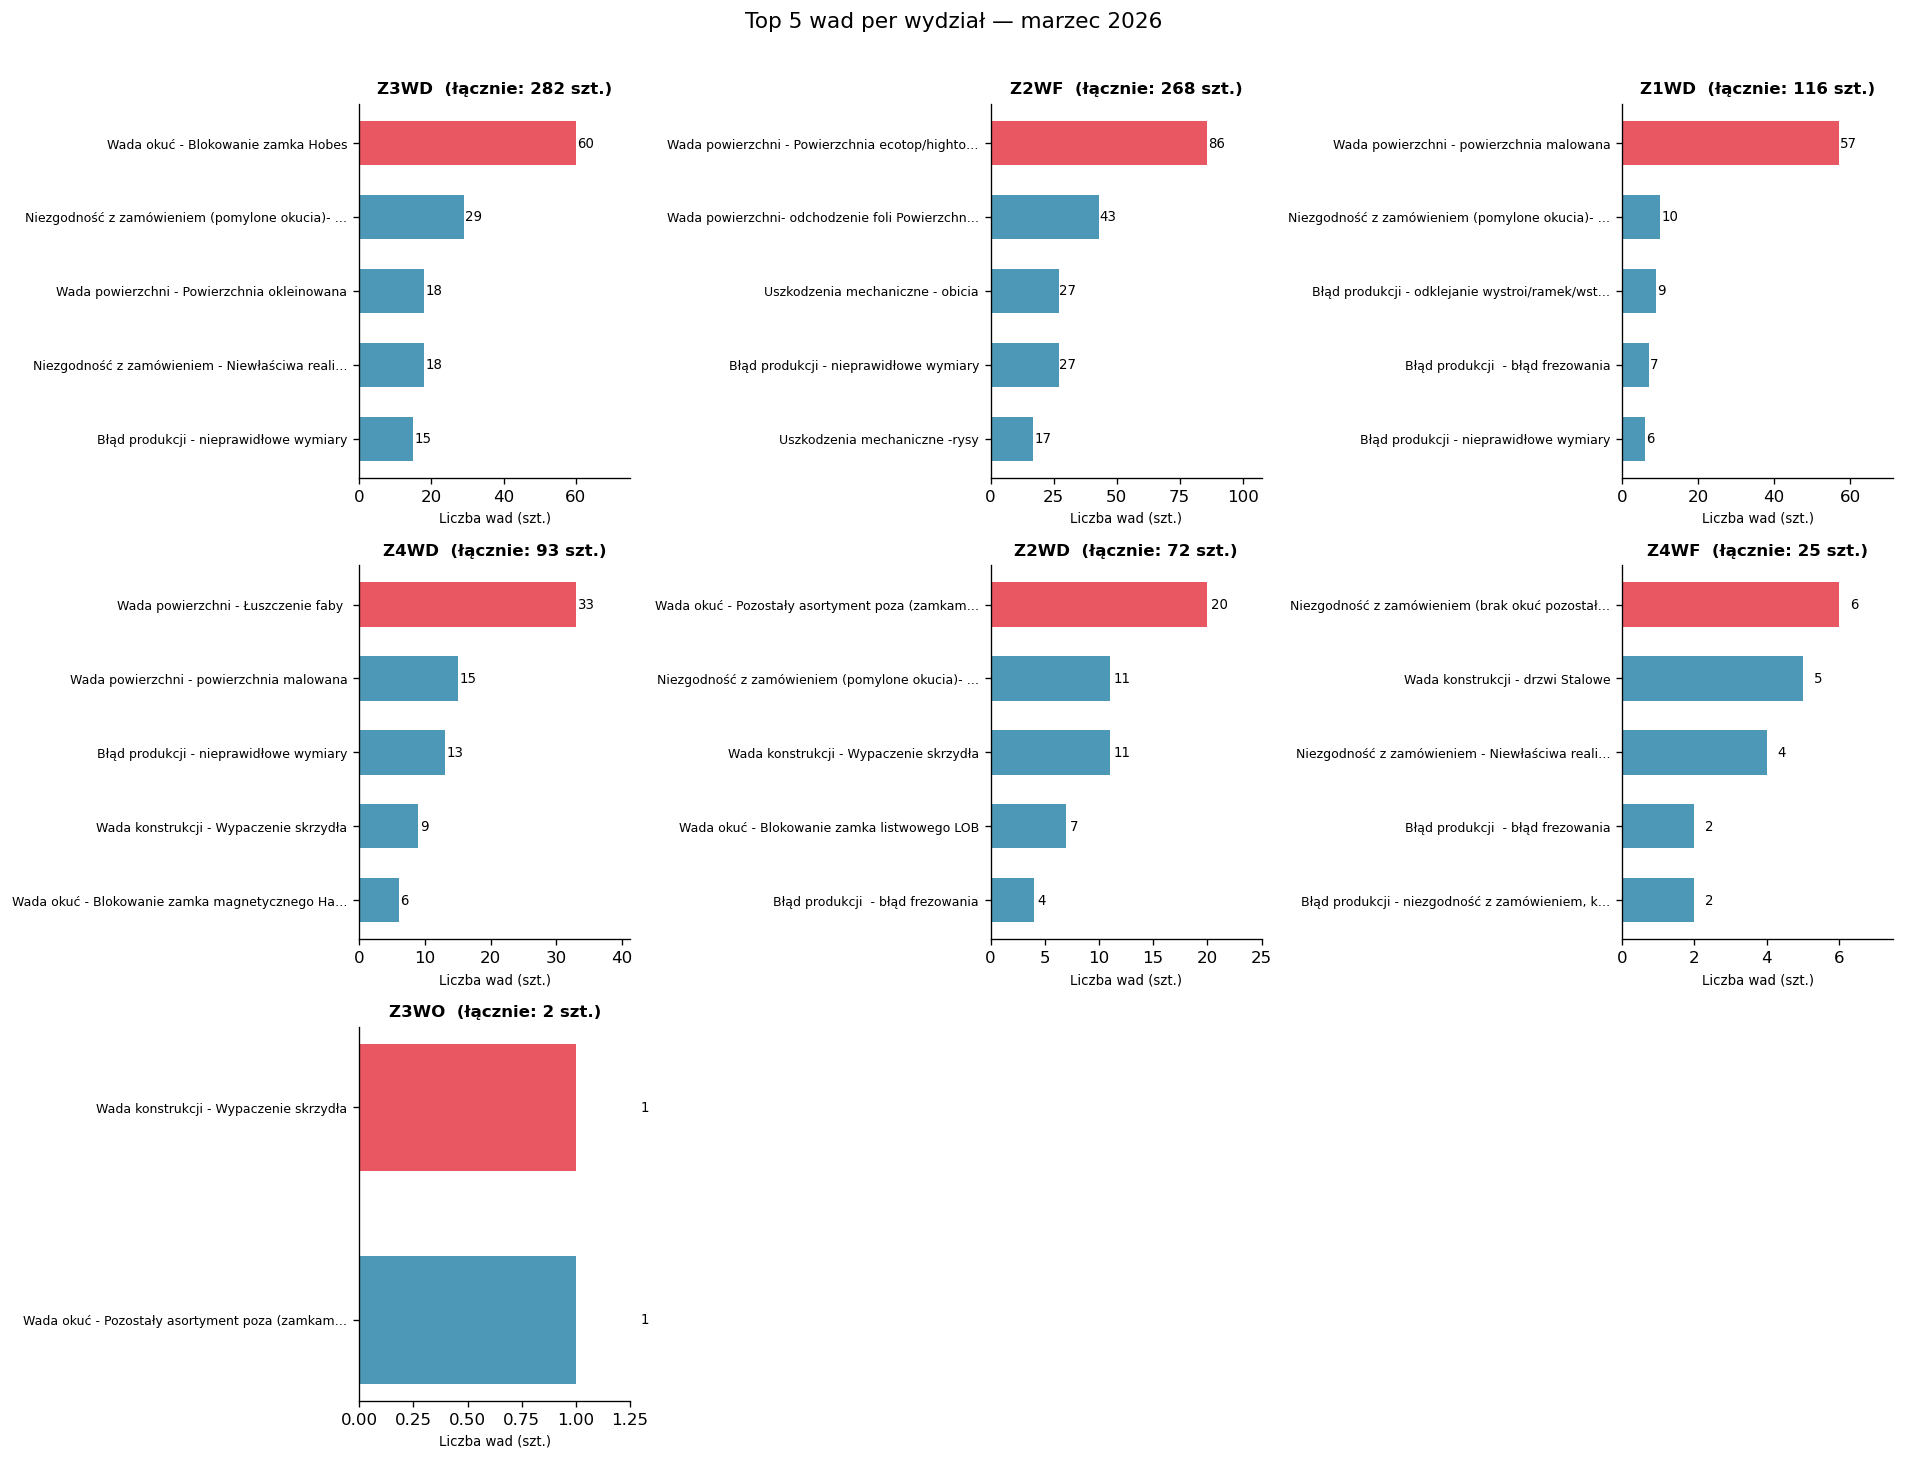

=== TOP 5 WAD PER WYDZIAŁ ===

--- Z3WD ---
  1. Wada okuć - Blokowanie zamka Hobes: 60 szt.
  2. Niezgodność z zamówieniem (pomylone okucia)- Niewłaściwa realizacja zamówienia -błąd w produkcji: 29 szt.
  3. Wada powierzchni - Powierzchnia okleinowana: 18 szt.
  4. Niezgodność z zamówieniem - Niewłaściwa realizacja zamówienia -błąd przy wprowadzaniu zamówienia: 18 szt.
  5. Błąd produkcji - nieprawidłowe wymiary: 15 szt.

--- Z2WF ---
  1. Wada powierzchni - Powierzchnia ecotop/hightop/unimat plus (poza odchodzeniem foli): 86 szt.
  2. Wada powierzchni- odchodzenie foli Powierzchnia ecotop/hightop/unimat plus: 43 szt.
  3. Uszkodzenia mechaniczne - obicia: 27 szt.
  4. Błąd produkcji - nieprawidłowe wymiary: 27 szt.
  5. Uszkodzenia mechaniczne -rysy: 17 szt.

--- Z1WD ---
  1. Wada powierzchni - powierzchnia malowana: 57 szt.
  2. Niezgodność z zamówieniem (pomylone okucia)- Niewłaściwa realizacja zamówienia -błąd w produkcji: 10 szt.
  3. Błąd produkcji - odklejanie wystroi/ramek/ws

In [11]:
wydzialy = df.groupby('Wydzial')['Ilosc'].sum().sort_values(ascending=False).index.tolist()
n_cols = 3
n_rows = int(np.ceil(len(wydzialy) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, w in enumerate(wydzialy):
    top5 = (df[df['Wydzial'] == w]
            .groupby('Wada')['Ilosc'].sum()
            .sort_values(ascending=False)
            .head(5))
    ax = axes[i]
    colors_top = ['#E63946' if j == 0 else '#2E86AB' for j in range(len(top5))]
    bars = ax.barh([skroc(w2, 45) for w2 in top5.index[::-1]], top5.values[::-1],
                   color=colors_top[::-1], alpha=0.85, height=0.6)
    for bar, val in zip(bars, top5.values[::-1]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
    total_w = df[df['Wydzial'] == w]['Ilosc'].sum()
    ax.set_title(f'{w}  (łącznie: {total_w} szt.)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Liczba wad (szt.)', fontsize=8)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.set_xlim(0, top5.max() * 1.25)

# Usuń puste panele
for j in range(len(wydzialy), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 wad per wydział — marzec 2026', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('top5_per_wydzial.png', bbox_inches='tight')
plt.show()

print('=== TOP 5 WAD PER WYDZIAŁ ===')
for w in wydzialy:
    print(f'\n--- {w} ---')
    top5 = (df[df['Wydzial'] == w]
            .groupby('Wada')['Ilosc'].sum()
            .sort_values(ascending=False)
            .head(5))
    for rank, (wada, ilosc) in enumerate(top5.items(), 1):
        print(f'  {rank}. {wada}: {ilosc} szt.')

---
## 9. Macierz produkt × wada <a id='9'></a>

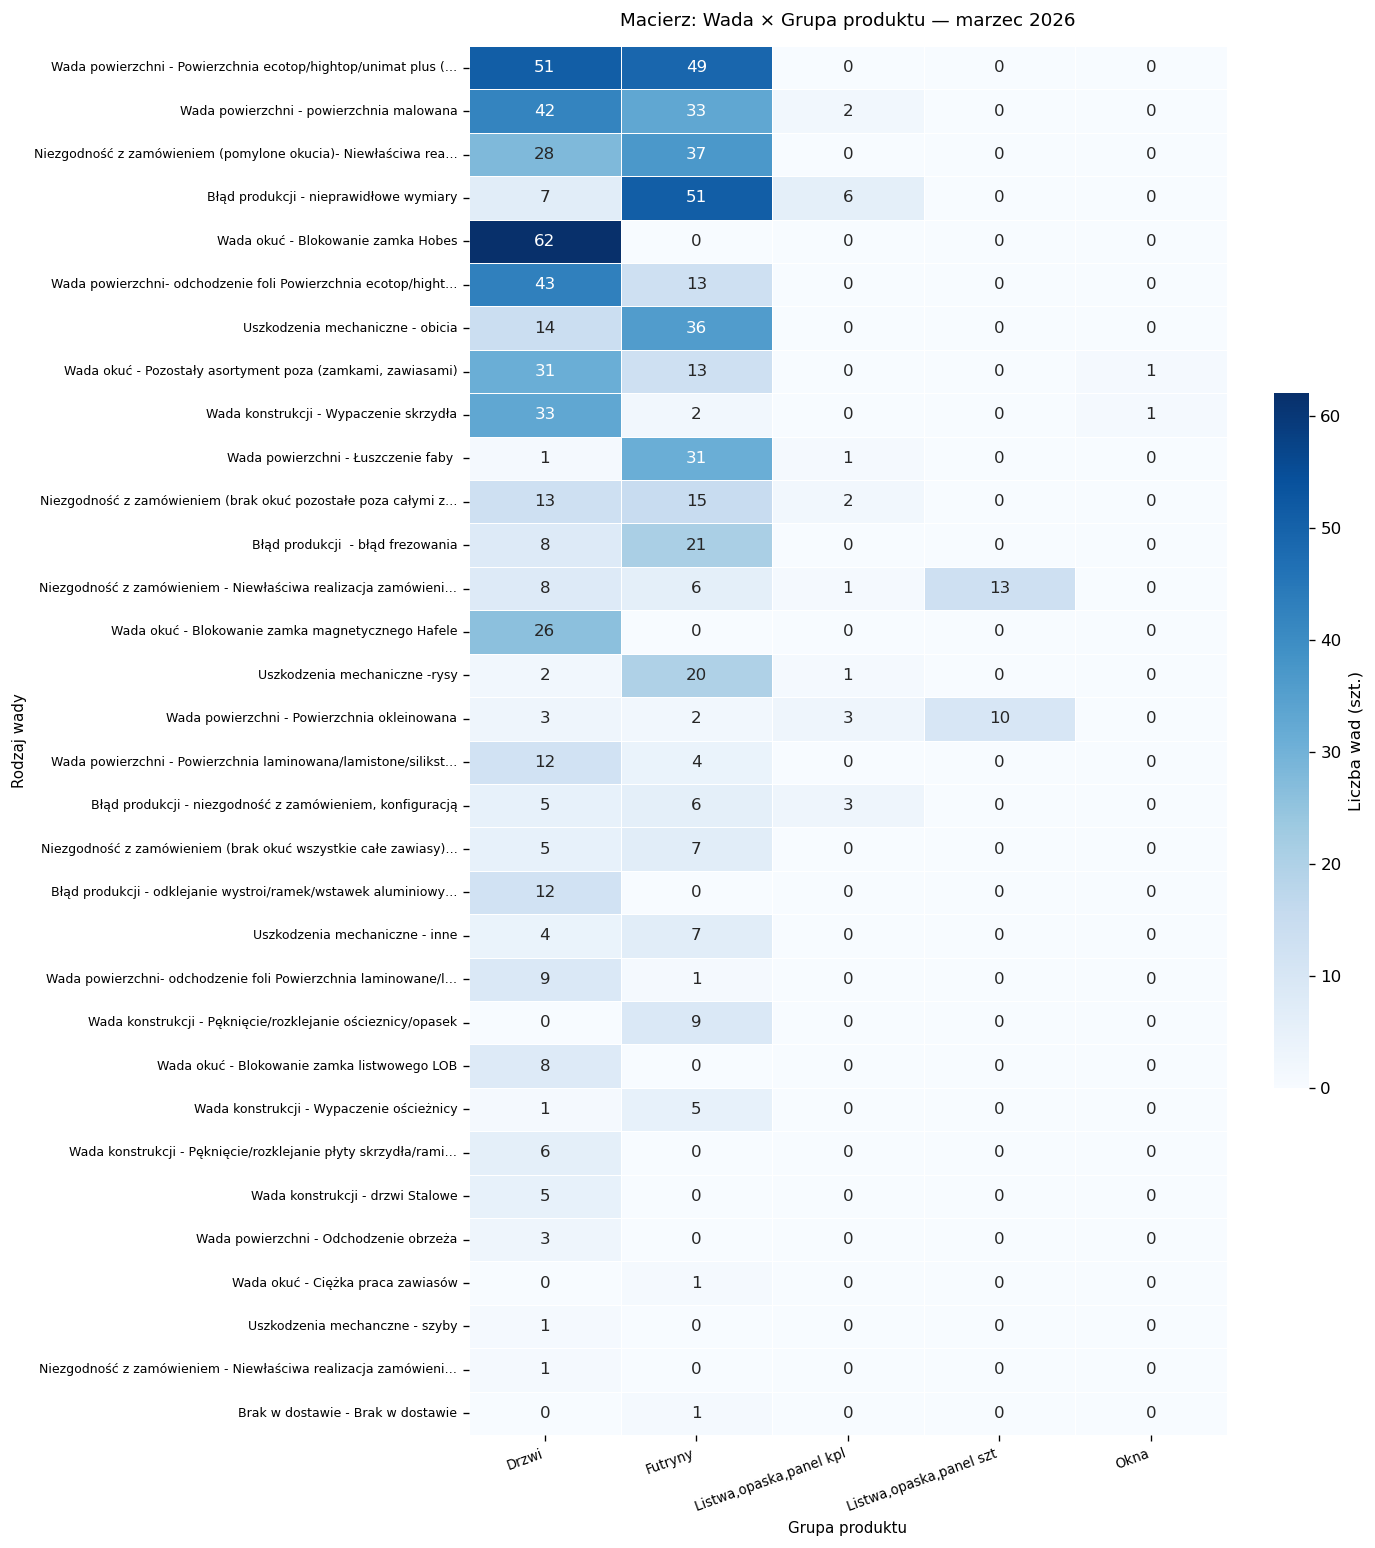

Macierz produkt × wada (z sumą):
Grupa                                                                   Drzwi  \
Wada                                                                            
Wada powierzchni - Powierzchnia ecotop/hightop/unimat plus (poza od...     51   
Wada powierzchni - powierzchnia malowana                                   42   
Niezgodność z zamówieniem (pomylone okucia)- Niewłaściwa realizacja...     28   
Błąd produkcji - nieprawidłowe wymiary                                      7   
Wada okuć - Blokowanie zamka Hobes                                         62   
Wada powierzchni- odchodzenie foli Powierzchnia ecotop/hightop/unim...     43   
Uszkodzenia mechaniczne - obicia                                           14   
Wada okuć - Pozostały asortyment poza (zamkami, zawiasami)                 31   
Wada konstrukcji - Wypaczenie skrzydła                                     33   
Wada powierzchni - Łuszczenie faby                                          

In [12]:
macierz = df.pivot_table(index='Wada', columns='Grupa', values='Ilosc', aggfunc='sum', fill_value=0)
macierz['SUMA'] = macierz.sum(axis=1)
macierz = macierz.sort_values('SUMA', ascending=False)

# Heatmap — bez kolumny SUMA
macierz_heat = macierz.drop(columns='SUMA')

# Skróć etykiety osi Y
short_labels = [skroc(w, 60) for w in macierz_heat.index]

fig, ax = plt.subplots(figsize=(12, 13))
sns.heatmap(
    macierz_heat, annot=True, fmt='d', cmap='Blues',
    linewidths=0.4, linecolor='white', ax=ax,
    cbar_kws={'label': 'Liczba wad (szt.)', 'shrink': 0.5}
)
ax.set_yticklabels(short_labels, fontsize=7.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
ax.set_title('Macierz: Wada × Grupa produktu — marzec 2026', fontsize=11, pad=12)
ax.set_ylabel('Rodzaj wady', fontsize=9)
ax.set_xlabel('Grupa produktu', fontsize=9)
plt.tight_layout()
plt.savefig('macierz_produkt_wada.png', bbox_inches='tight')
plt.show()

print('Macierz produkt × wada (z sumą):')
pd.set_option('display.max_colwidth', 70)
print(macierz)

---
## 10. Export raportu XLSX <a id='10'></a>
Generuje plik `raport_analiza_marzec_2026.xlsx` z wieloma arkuszami.

In [13]:
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl import Workbook
from openpyxl.formatting.rule import ColorScaleRule

def styl_naglowek(ws, row=1):
    fill = PatternFill('solid', fgColor='1F4E79')
    font = Font(bold=True, color='FFFFFF', size=10)
    for cell in ws[row]:
        cell.fill = fill
        cell.font = font
        cell.alignment = Alignment(horizontal='center', wrap_text=True)

def zapisz_df(ws, df_in, title=None):
    if title:
        ws.append([title])
        ws['A1'].font = Font(bold=True, size=12, color='1F4E79')
        ws.append([])
    for r in dataframe_to_rows(df_in, index=True, header=True):
        ws.append(r)
    styl_naglowek(ws, row=3 if title else 1)

wb = Workbook()

# === Arkusz 1: Dane surowe ===
ws1 = wb.active
ws1.title = 'Dane'
for r in dataframe_to_rows(df, index=False, header=True):
    ws1.append(r)
styl_naglowek(ws1)
for col in ws1.columns:
    ws1.column_dimensions[col[0].column_letter].width = 30

# === Arkusz 2: Ranking wydziałów ===
ws2 = wb.create_sheet('Wydziały')
tab_w = (df.groupby('Wydzial')['Ilosc'].sum()
           .sort_values(ascending=False)
           .reset_index()
           .rename(columns={'Wydzial': 'Wydział', 'Ilosc': 'Ilość'}))
tab_w['Udział %'] = (tab_w['Ilość'] / TOTAL * 100).round(1)
tab_w['Skumulowany %'] = tab_w['Udział %'].cumsum().round(1)
for r in dataframe_to_rows(tab_w, index=False, header=True):
    ws2.append(r)
styl_naglowek(ws2)
for col in ws2.columns:
    ws2.column_dimensions[col[0].column_letter].width = 20

# === Arkusz 3: Kategorie wad ===
ws3 = wb.create_sheet('Kategorie')
tab_k = (df.groupby('Kategoria')['Ilosc'].sum()
           .sort_values(ascending=False)
           .reset_index()
           .rename(columns={'Ilosc': 'Ilość'}))
tab_k['Udział %'] = (tab_k['Ilość'] / TOTAL * 100).round(1)
for r in dataframe_to_rows(tab_k, index=False, header=True):
    ws3.append(r)
styl_naglowek(ws3)
for col in ws3.columns:
    ws3.column_dimensions[col[0].column_letter].width = 35

# === Arkusz 4: Pareto wad ===
ws4 = wb.create_sheet('Pareto')
pareto_tab = (df.groupby('Wada')['Ilosc'].sum()
                .sort_values(ascending=False)
                .reset_index()
                .rename(columns={'Ilosc': 'Ilość'}))
pareto_tab['Udział %'] = (pareto_tab['Ilość'] / TOTAL * 100).round(1)
pareto_tab['Skumulowany %'] = pareto_tab['Udział %'].cumsum().round(1)
pareto_tab['Próg 80%'] = pareto_tab['Skumulowany %'].apply(lambda x: '✓' if x <= 80 else '')
for r in dataframe_to_rows(pareto_tab, index=False, header=True):
    ws4.append(r)
styl_naglowek(ws4)
ws4.column_dimensions['A'].width = 80
for col_letter in ['B','C','D','E']:
    ws4.column_dimensions[col_letter].width = 16

# === Arkusz 5: Heatmap Wydział × Kategoria ===
ws5 = wb.create_sheet('Heatmap Wydział')
pivot5 = df.pivot_table(index='Wydzial', columns='Kategoria', values='Ilosc', aggfunc='sum', fill_value=0)
pivot5['SUMA'] = pivot5.sum(axis=1)
pivot5 = pivot5.sort_values('SUMA', ascending=False).reset_index()
for r in dataframe_to_rows(pivot5, index=False, header=True):
    ws5.append(r)
styl_naglowek(ws5)
for col in ws5.columns:
    ws5.column_dimensions[col[0].column_letter].width = 28
# Color scale na danych
last_col = ws5.max_column
last_row = ws5.max_row
rule = ColorScaleRule(start_type='num', start_value=0, start_color='FFFFFF',
                      end_type='num', end_value=pivot5['SUMA'].max(), end_color='FF0000')
ws5.conditional_formatting.add(f'B2:{ws5.cell(last_row, last_col).coordinate}', rule)

# === Arkusz 6: PL vs EX ===
ws6 = wb.create_sheet('PL vs EX')
pivot6 = df.pivot_table(index='Kierunek', columns='Kategoria', values='Ilosc', aggfunc='sum', fill_value=0)
pivot6['SUMA'] = pivot6.sum(axis=1)
pivot6 = pivot6.reset_index()
for r in dataframe_to_rows(pivot6, index=False, header=True):
    ws6.append(r)
styl_naglowek(ws6)
for col in ws6.columns:
    ws6.column_dimensions[col[0].column_letter].width = 28

# === Arkusz 7: Grupy produktów ===
ws7 = wb.create_sheet('Grupy produktów')
pivot7 = df.pivot_table(index='Grupa', columns='Kategoria', values='Ilosc', aggfunc='sum', fill_value=0)
pivot7['SUMA'] = pivot7.sum(axis=1)
pivot7 = pivot7.sort_values('SUMA', ascending=False).reset_index()
for r in dataframe_to_rows(pivot7, index=False, header=True):
    ws7.append(r)
styl_naglowek(ws7)
for col in ws7.columns:
    ws7.column_dimensions[col[0].column_letter].width = 28

# === Arkusz 8: Top5 per wydział ===
ws8 = wb.create_sheet('Top5 per wydział')
ws8.append(['Wydział', 'Rank', 'Wada', 'Ilość', 'Udział w wydziale %'])
styl_naglowek(ws8)
for w in wydzialy:
    top5 = (df[df['Wydzial'] == w]
            .groupby('Wada')['Ilosc'].sum()
            .sort_values(ascending=False)
            .head(5))
    total_w = df[df['Wydzial'] == w]['Ilosc'].sum()
    for rank, (wada, ilosc) in enumerate(top5.items(), 1):
        ws8.append([w, rank, wada, ilosc, round(ilosc/total_w*100, 1)])
ws8.column_dimensions['A'].width = 12
ws8.column_dimensions['B'].width = 8
ws8.column_dimensions['C'].width = 80
ws8.column_dimensions['D'].width = 12
ws8.column_dimensions['E'].width = 22

# === Arkusz 9: Macierz Wada × Produkt ===
ws9 = wb.create_sheet('Macierz Wada-Produkt')
macierz9 = df.pivot_table(index='Wada', columns='Grupa', values='Ilosc', aggfunc='sum', fill_value=0)
macierz9['SUMA'] = macierz9.sum(axis=1)
macierz9 = macierz9.sort_values('SUMA', ascending=False).reset_index()
for r in dataframe_to_rows(macierz9, index=False, header=True):
    ws9.append(r)
styl_naglowek(ws9)
ws9.column_dimensions['A'].width = 80
for col_letter in [chr(c) for c in range(ord('B'), ord('B') + ws9.max_column)]:
    try:
        ws9.column_dimensions[col_letter].width = 22
    except:
        pass

PLIK_XLSX = 'raport_analiza_marzec_2026.xlsx'
wb.save(PLIK_XLSX)
print(f'✓ Zapisano: {PLIK_XLSX}')
print(f'  Arkusze: {[s.title for s in wb.worksheets]}')

✓ Zapisano: raport_analiza_marzec_2026.xlsx
  Arkusze: ['Dane', 'Wydziały', 'Kategorie', 'Pareto', 'Heatmap Wydział', 'PL vs EX', 'Grupy produktów', 'Top5 per wydział', 'Macierz Wada-Produkt']


---
## 11. Export CSV dla PowerBI <a id='11'></a>
Dane wzbogacone o kolumnę `Kategoria_wady` — gotowe do importu w PowerBI.

In [14]:
df_export = df.rename(columns={
    'Wydzial': 'Wydział',
    'Kierunek': 'Kierunek',
    'Grupa': 'Grupa_ogolna',
    'Wada': 'Wada',
    'Ilosc': 'Ilosc',
    'Kategoria': 'Kategoria_wady'
})

PLIK_CSV = 'wady_powerbi_marzec_2026.csv'
df_export.to_csv(PLIK_CSV, index=False, encoding='utf-8-sig', sep=';')
print(f'✓ Zapisano: {PLIK_CSV}')
print(f'  Wiersze: {len(df_export)}, Kolumny: {list(df_export.columns)}')
print(f'  Kodowanie: UTF-8 z BOM (utf-8-sig) — czytelne w Excel PL')
print(f'  Separator: średnik (;) — standard dla polskiego Excel/PowerBI')
df_export.head()

✓ Zapisano: wady_powerbi_marzec_2026.csv
  Wiersze: 178, Kolumny: ['Wydział', 'Kierunek', 'Grupa_ogolna', 'Wada', 'Ilosc', 'Kategoria_wady']
  Kodowanie: UTF-8 z BOM (utf-8-sig) — czytelne w Excel PL
  Separator: średnik (;) — standard dla polskiego Excel/PowerBI


,Wydział,Kierunek,Grupa_ogolna,Wada,Ilosc,Kategoria_wady
0,Z2WF,PL,Futryny,Brak w dostawie - Brak w dostawie,1,Brak w dostawie
1,Z1WD,PL,Drzwi,Błąd produkcji - błąd frezowania,1,Błędy produkcji
2,Z1WD,PL,Futryny,Błąd produkcji - błąd frezowania,6,Błędy produkcji
3,Z2WD,PL,Drzwi,Błąd produkcji - błąd frezowania,4,Błędy produkcji
4,Z2WF,EX,Futryny,Błąd produkcji - błąd frezowania,1,Błędy produkcji


---
## Podsumowanie

| Analiza | Plik wynikowy |
|---|---|
| Pareto 80/20 | `pareto_wady.png` |
| Ranking wydziałów | `ranking_wydzialow.png` |
| Kategorie wad | `kategorie_wad.png` |
| Heatmap Wydział × Kategoria | `heatmap_wydzial_kategoria.png` |
| PL vs EX | `pl_vs_ex.png` |
| Grupy produktów | `grupy_produktow.png` |
| Top 5 per wydział | `top5_per_wydzial.png` |
| Macierz produkt × wada | `macierz_produkt_wada.png` |
| Raport XLSX (9 arkuszy) | `raport_analiza_marzec_2026.xlsx` |
| CSV dla PowerBI | `wady_powerbi_marzec_2026.csv` |

### Kluczowe wnioski
- **Z3WD + Z2WF** = 64% wszystkich wad → priorytet działań naprawczych
- **Wady powierzchni** dominują (36,5%) → problem z procesem wykończenia
- **Drzwi + Futryny** = 95% wad → pozostałe grupy produktów bez istotnych problemów
- Analiza Pareto wskaże dokładnie, ile wad (z 32) odpowiada za 80% problemu
- Rynek **EX** ma inny profil wad niż **PL** → osobne podejście do jakości eksportowej